# 02 - Supervised Modeling V2

## Clasificación de entregas tardías con variable objetivo ajustada

Este notebook continúa el proceso de modelado supervisado del proyecto logístico.

En el primer intento se utilizó la variable `entrega_tardia`, pero se detectó un fuerte desbalance de clases. Por eso, en este notebook se revisa críticamente esa variable y se propone una nueva versión:

`entrega_tardia_v2`

La finalidad es construir una variable objetivo más interpretable y útil para entrenar modelos de clasificación.


## Objetivo del notebook

Este notebook busca:

1. Revisar por qué la variable `entrega_tardia` original generó problemas.
2. Justificar la creación de una nueva variable objetivo basada en un umbral de 7 días.
3. Crear `entrega_tardia_v2`.
4. Entrenar modelos supervisados de clasificación.
5. Comparar resultados iniciales entre modelos.
6. Dejar una base sólida para evaluación y optimización posterior.


# 1. Configuración inicial

Se cargan las librerías necesarias para análisis, visualización, preprocesamiento y modelado con Scikit-learn.


In [1]:
# Conecta el notebook con el proyecto Kedro.
# Esto permite usar catalog.load("dataset_modelo") directamente.
%load_ext kedro.ipython

# Librerías principales para manipulación y análisis de datos.
import pandas as pd
import numpy as np

# Librerías para visualización.
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de Scikit-learn para dividir datos y crear pipelines.
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Herramientas para tratar nulos y transformar variables.
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Modelos de clasificación.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Métricas de evaluación.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Configuración visual general.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Configuración para ver más columnas.
pd.set_option("display.max_columns", None)


The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


# 2. Carga del dataset final

Se carga el dataset final generado por Kedro:

`dataset_modelo`

Este dataset ya pasó por los pipelines de ingesta, limpieza, transformación y validación.


In [2]:
# Cargamos el dataset final desde el catálogo Kedro.
df = catalog.load("dataset_modelo")

# Mostramos las primeras filas para verificar la carga.
df.head()


[05/09/26 19:22:08] INFO     Loading data from dataset_modelo (CSVDataset)...                  ]8;id=1997797;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=1997798;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,tipo_carga,estado,fecha_entrega,origen,destino,distancia_km,tiempo_estimado_hrs,tipo_via,peaje_total,placa,tipo,capacidad_kg,capacidad_m3,año_fabricacion,estado_vehiculo,km_recorridos,cantidad_incidencias,costo_total_incidencias,tipo_incidencia_principal,tiene_incidencia,dias_entrega,velocidad_promedio_km_h,uso_capacidad_kg,uso_capacidad_m3,entrega_tardia
0,1.0,2023-01-01,39.0,46.0,12675.8,28.48,peligrosa,entregado,2023-01-05,valparaíso,chillán,919.3,16.7,urbana,1950.0,ouuc-52,camión,10000.0,20.5,2022.0,en mantención,17043.0,0.0,0.0,sin incidencia,0.0,4.0,55.047904,1.26758,1.389268,1
1,2.0,NaN,3.0,27.0,13.6,24.93,peligrosa,entregado,2023-01-05,rancagua,rengo,679.6,18.4,urbana,2447.0,fgkf-38,van,1000.0,22.1,2010.0,operativo,88004.0,0.0,0.0,sin incidencia,0.0,7.0,36.934783,0.01360,1.128054,1
2,3.0,2023-01-02,73.0,18.0,2536.0,50.55,refrigerada,entregado,NaN,maipú,san antonio,468.4,5.2,ruta nacional,11768.0,agdn-22,furgón,20000.0,38.9,2023.0,en mantención,243705.0,0.0,0.0,sin incidencia,0.0,7.0,90.076923,0.12680,1.299486,1
3,4.0,2023-01-03,49.0,45.0,466.0,13.88,peligrosa,en tránsito,2023-01-07,las condes,osorno,1642.4,18.9,ruta nacional,7202.0,ialh-88,van,1000.0,25.3,2015.0,operativo,224573.5,1.0,1747372.0,desvío de ruta,1.0,4.0,86.899471,0.46600,0.548617,1
4,5.0,NaN,17.0,36.0,4928.9,0.44,refrigerada,retrasado,2023-01-07,maipú,rancagua,1556.6,17.9,urbana,3799.0,glfy-29,camioneta,5000.0,49.1,2023.0,operativo,138259.0,0.0,0.0,sin incidencia,0.0,7.0,86.960894,0.98578,0.008961,1


# 3. Diagnóstico de la variable objetivo original

En el primer enfoque se utilizó la variable `entrega_tardia`.

Esta variable fue creada comparando los días reales de entrega contra el tiempo estimado. Sin embargo, se observó que casi todos los registros quedaron clasificados como entrega tardía.

Antes de cambiar el enfoque, revisamos esta situación con datos.


In [3]:
# Distribución absoluta de la variable original.
df["entrega_tardia"].value_counts()



entrega_tardia
1    1002
0      28
Name: count, dtype: int64

In [4]:
# Distribución porcentual de la variable original.
df["entrega_tardia"].value_counts(normalize=True) * 100



entrega_tardia
1    97.281553
0     2.718447
Name: proportion, dtype: float64

## Interpretación

La variable original `entrega_tardia` presenta un desbalance muy fuerte.  
Si casi todos los registros pertenecen a una sola clase, el modelo puede obtener un accuracy alto simplemente prediciendo siempre la clase mayoritaria.

Esto significa que el accuracy puede ser engañoso y que el modelo realmente no estaría aprendiendo patrones útiles.


# 4. Revisión de la regla original

La regla original comparaba:

`dias_entrega` contra `tiempo_estimado_hrs / 24`

El problema es que `tiempo_estimado_hrs / 24` suele ser menor a 1 día, mientras que `dias_entrega` suele estar entre 4 y 10 días. Por eso, casi todos los registros quedan marcados como tardíos.


In [5]:
# Creamos una columna auxiliar para convertir el tiempo estimado desde horas a días.
# Esta columna sirve solo para análisis.
df["tiempo_estimado_dias"] = df["tiempo_estimado_hrs"] / 24

# Revisamos una muestra de las variables relacionadas.
df[[
    "dias_entrega",
    "tiempo_estimado_hrs",
    "tiempo_estimado_dias",
    "entrega_tardia"
]].head(15)


,dias_entrega,tiempo_estimado_hrs,tiempo_estimado_dias,entrega_tardia
0,4.0,16.7,0.695833,1
1,7.0,18.4,0.766667,1
2,7.0,5.2,0.216667,1
3,4.0,18.9,0.787500,1
4,7.0,17.9,0.745833,1
5,7.0,16.7,0.695833,1
6,7.0,3.0,0.125000,1
7,7.0,16.5,0.687500,1
8,7.0,11.7,0.487500,1
9,7.0,3.0,0.125000,1


In [6]:
# Calculamos la diferencia entre días reales de entrega y días estimados.
df["diferencia_dias"] = df["dias_entrega"] - df["tiempo_estimado_dias"]

# Revisamos estadísticas descriptivas.
df[[
    "dias_entrega",
    "tiempo_estimado_dias",
    "diferencia_dias",
    "entrega_tardia"
]].describe()


,dias_entrega,tiempo_estimado_dias,diferencia_dias,entrega_tardia
count,1030.000000,1002.000000,1002.000000,1030.000000
mean,7.041748,0.512458,6.532452,0.972816
std,0.817213,0.277076,0.862615,0.162700
min,4.000000,0.037500,3.129167,0.000000
25%,7.000000,0.262500,6.233333,1.000000
50%,7.000000,0.508333,6.491667,1.000000
75%,7.000000,0.729167,6.787500,1.000000
max,10.000000,0.987500,9.875000,1.000000


## Conclusión del diagnóstico

La variable original `entrega_tardia` no está mal como idea, pero su definición quedó demasiado estricta.

El criterio usado genera una clase positiva excesivamente dominante. Por eso se propone construir una nueva variable objetivo más interpretable y equilibrada.


# 5. Nueva definición de variable objetivo

Se propone crear una nueva variable:

`entrega_tardia_v2`

La regla será:

`entrega_tardia_v2 = 1` si `dias_entrega > 7`  
`entrega_tardia_v2 = 0` si `dias_entrega <= 7`

## ¿Por qué usar 7 días?

El umbral de 7 días es razonable porque:

- representa una semana completa de entrega;
- es fácil de explicar desde el punto de vista logístico;
- permite diferenciar entregas normales de entregas con una duración mayor;
- genera una variable más interpretable para clasificación;
- evita el desbalance extremo observado en la variable original.


In [7]:
# Creamos una nueva variable objetivo.
# Si el envío tarda más de 7 días, se considera entrega tardía.
df["entrega_tardia_v2"] = (df["dias_entrega"] > 7).astype(int)

# Mostramos las primeras filas para confirmar la creación de la variable.
df[["dias_entrega", "entrega_tardia", "entrega_tardia_v2"]].head(20)


,dias_entrega,entrega_tardia,entrega_tardia_v2
0,4.0,1,0
1,7.0,1,0
2,7.0,1,0
3,4.0,1,0
4,7.0,1,0
5,7.0,1,0
6,7.0,1,0
7,7.0,1,0
8,7.0,1,0
9,7.0,1,0


# 6. Distribución de la nueva variable objetivo

Ahora revisamos si `entrega_tardia_v2` presenta una distribución más útil para modelado.


In [8]:
# Distribución absoluta.
df["entrega_tardia_v2"].value_counts()



entrega_tardia_v2
0    929
1    101
Name: count, dtype: int64

In [9]:
# Distribución porcentual.
df["entrega_tardia_v2"].value_counts(normalize=True) * 100



entrega_tardia_v2
0    90.194175
1     9.805825
Name: proportion, dtype: float64

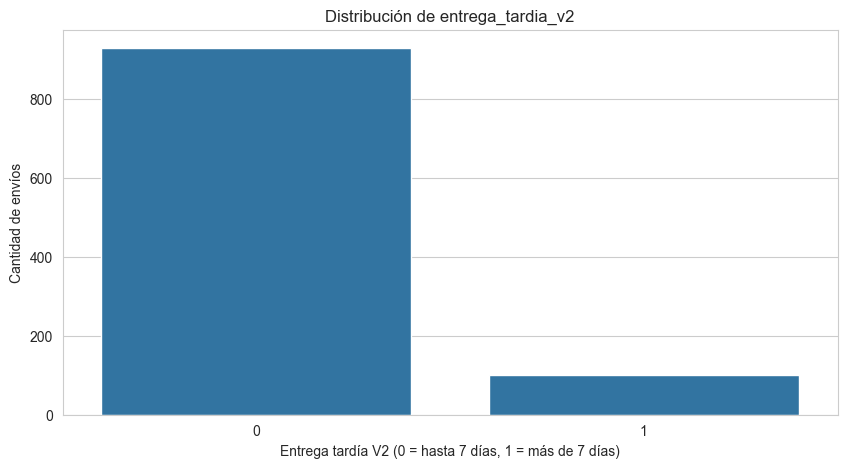

In [10]:
# Visualizamos la nueva distribución.
sns.countplot(data=df, x="entrega_tardia_v2")

plt.title("Distribución de entrega_tardia_v2")
plt.xlabel("Entrega tardía V2 (0 = hasta 7 días, 1 = más de 7 días)")
plt.ylabel("Cantidad de envíos")

plt.show()


## Interpretación esperada

No se busca que las clases sean perfectamente 50/50, pero sí evitar una situación donde una clase represente casi todo el dataset.

Una distribución menos extrema permite entrenar y evaluar modelos de manera más realista.


# 7. Selección de variables predictoras

Para entrenar el modelo se seleccionan variables relacionadas con la operación logística.

Se evita usar variables que podrían generar fuga de información, como:

- `dias_entrega`, porque se usa para construir la variable objetivo;
- `fecha_entrega`, porque solo se conoce al finalizar el envío;
- `entrega_tardia`, porque es la variable objetivo antigua;
- `entrega_tardia_v2`, porque será el objetivo actual.


In [11]:
# Variables seleccionadas para explicar o predecir la entrega tardía.
variables_modelo = [
    "distancia_km",
    "tiempo_estimado_hrs",
    "peso_kg",
    "volumen_m3",
    "capacidad_kg",
    "capacidad_m3",
    "cantidad_incidencias",
    "tiene_incidencia",
    "uso_capacidad_kg",
    "uso_capacidad_m3",
    "velocidad_promedio_km_h",
    "tipo_via",
    "tipo_carga",
    "estado_vehiculo"
]

# Variable objetivo nueva.
objetivo = "entrega_tardia_v2"

# Creamos X e y.
X = df[variables_modelo]
y = df[objetivo]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)


Dimensiones de X: (1030, 14)
Dimensiones de y: (1030,)


## Justificación de variables seleccionadas

Las variables seleccionadas representan factores logísticos que podrían influir en la duración de una entrega.

Ejemplos:

- `distancia_km`: rutas más largas podrían implicar mayor riesgo de demora.
- `peso_kg` y `volumen_m3`: cargas más pesadas o voluminosas pueden afectar la operación.
- `capacidad_kg` y `capacidad_m3`: indican características del vehículo asignado.
- `cantidad_incidencias`: mayor cantidad de incidencias podría asociarse a retrasos.
- `uso_capacidad_kg`: mide qué tan exigido va el vehículo.
- `velocidad_promedio_km_h`: aproxima la eficiencia esperada del recorrido.
- `tipo_via`, `tipo_carga` y `estado_vehiculo`: agregan contexto categórico relevante.


# 8. Revisión de valores nulos en variables seleccionadas

Antes de entrenar, se revisan los nulos únicamente en las variables seleccionadas para el modelo.


In [12]:
# Contamos nulos por variable predictora.
nulos_modelo = X.isnull().sum().sort_values(ascending=False)

nulos_modelo[nulos_modelo > 0]



capacidad_kg           31
capacidad_m3           31
estado_vehiculo        31
tiempo_estimado_hrs    28
tipo_via               28
distancia_km           28
dtype: int64

## Tratamiento de nulos

Los nulos no se imputarán manualmente sobre el DataFrame original.

En su lugar, se utilizará un pipeline de Scikit-learn que imputará automáticamente:

- variables numéricas con la mediana;
- variables categóricas con el valor más frecuente.

Esto mantiene el flujo reproducible y evita modificar directamente el dataset original.


# 9. Separación de variables numéricas y categóricas

Los modelos de Machine Learning necesitan que los datos estén en formato numérico. Por eso se separan las variables numéricas y categóricas para aplicar transformaciones distintas.


In [13]:
# Detectamos variables numéricas.
variables_numericas = X.select_dtypes(include=np.number).columns.tolist()

# Detectamos variables categóricas.
variables_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)


Variables numéricas:
['distancia_km', 'tiempo_estimado_hrs', 'peso_kg', 'volumen_m3', 'capacidad_kg', 'capacidad_m3', 'cantidad_incidencias', 'tiene_incidencia', 'uso_capacidad_kg', 'uso_capacidad_m3', 'velocidad_promedio_km_h']

Variables categóricas:
['tipo_via', 'tipo_carga', 'estado_vehiculo']


# 10. Pipeline de preprocesamiento

Se construye un preprocesador que realizará automáticamente las transformaciones necesarias antes del entrenamiento.

Para variables numéricas:

1. Imputación con mediana.
2. Escalado con StandardScaler.

Para variables categóricas:

1. Imputación con valor más frecuente.
2. Codificación OneHotEncoder.


In [14]:
# Pipeline para variables numéricas.
transformador_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline para variables categóricas.
transformador_categorico = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer aplica cada pipeline al grupo de columnas correspondiente.
preprocesador = ColumnTransformer([
    ("num", transformador_numerico, variables_numericas),
    ("cat", transformador_categorico, variables_categoricas)
])


# 11. División en entrenamiento y prueba

Se divide el dataset en:

- 80% para entrenamiento;
- 20% para prueba.

Además, se utiliza `stratify=y` para mantener una proporción similar de clases en ambos conjuntos.


In [15]:
# División reproducible del dataset.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nDistribución en y_train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribución en y_test:")
print(y_test.value_counts(normalize=True) * 100)


X_train: (824, 14)
X_test: (206, 14)

Distribución en y_train:
entrega_tardia_v2
0    90.169903
1     9.830097
Name: proportion, dtype: float64

Distribución en y_test:
entrega_tardia_v2
0    90.291262
1     9.708738
Name: proportion, dtype: float64


# 12. Función auxiliar para evaluar modelos

Se crea una función para evitar repetir código al evaluar cada modelo.

La función calculará:

- Accuracy
- Precision
- Recall
- F1-score
- Classification report
- Matriz de confusión


In [16]:
def evaluar_modelo(nombre_modelo, modelo, X_train, X_test, y_train, y_test):
    """Entrena y evalúa un modelo de clasificación.

    Parameters
    ----------
    nombre_modelo : str
        Nombre del modelo para mostrar resultados.
    modelo : sklearn Pipeline
        Pipeline que incluye preprocesamiento y modelo.
    X_train, X_test : DataFrame
        Variables predictoras de entrenamiento y prueba.
    y_train, y_test : Series
        Variable objetivo de entrenamiento y prueba.

    Returns
    -------
    dict
        Diccionario con métricas principales del modelo.
    """

    # Entrenamiento del modelo.
    modelo.fit(X_train, y_train)

    # Predicciones sobre datos de prueba.
    y_pred = modelo.predict(X_test)

    # Cálculo de métricas principales.
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"===== {nombre_modelo} =====")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Matriz de confusión.
    matriz = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz)

    disp.plot()
    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.show()

    return {
        "modelo": nombre_modelo,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }


# 13. Modelo 1 — Logistic Regression

La regresión logística se utiliza como modelo base para clasificación binaria.

Ventajas:

- rápida de entrenar;
- fácil de interpretar;
- útil como línea base inicial.


===== Logistic Regression =====
Accuracy : 0.6165
Precision: 0.1067
Recall   : 0.4000
F1-score : 0.1684

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.64      0.75       186
           1       0.11      0.40      0.17        20

    accuracy                           0.62       206
   macro avg       0.51      0.52      0.46       206
weighted avg       0.83      0.62      0.69       206



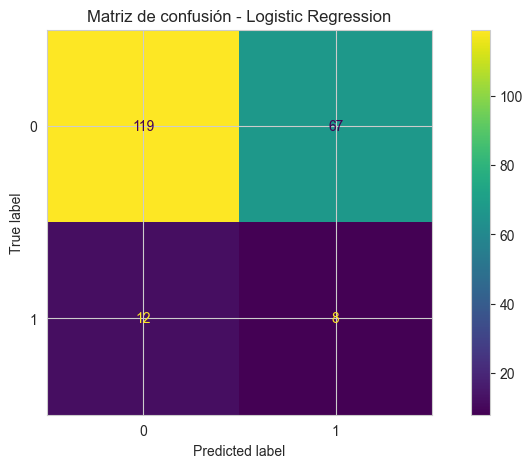

In [17]:
# Pipeline completo: preprocesamiento + modelo.
modelo_logistic = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight="balanced"
    ))
])

# Evaluamos el modelo.
resultado_logistic = evaluar_modelo(
    "Logistic Regression",
    modelo_logistic,
    X_train,
    X_test,
    y_train,
    y_test
)


## Nota sobre `class_weight="balanced"`

Se utiliza `class_weight="balanced"` porque, aunque `entrega_tardia_v2` debería ser más equilibrada que la variable original, puede seguir existiendo cierto desbalance.

Este parámetro le indica al modelo que preste más atención a la clase minoritaria.


# 14. Modelo 2 — Decision Tree

El árbol de decisión permite capturar relaciones no lineales entre variables.

Ventajas:

- fácil de interpretar;
- no requiere supuestos lineales;
- permite observar reglas de decisión simples.


===== Decision Tree =====
Accuracy : 0.7621
Precision: 0.1463
Recall   : 0.3000
F1-score : 0.1967

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.81      0.86       186
           1       0.15      0.30      0.20        20

    accuracy                           0.76       206
   macro avg       0.53      0.56      0.53       206
weighted avg       0.84      0.76      0.80       206



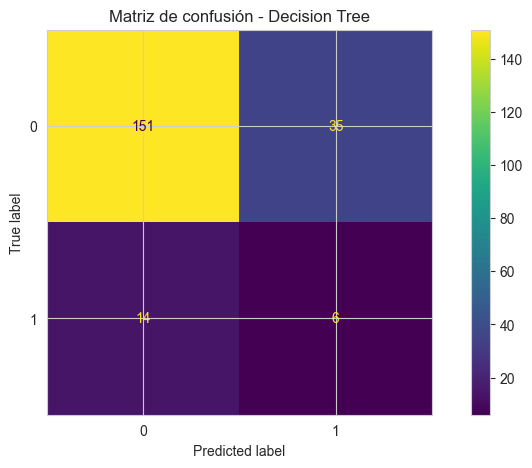

In [18]:
modelo_tree = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", DecisionTreeClassifier(
        random_state=42,
        max_depth=5,
        class_weight="balanced"
    ))
])

resultado_tree = evaluar_modelo(
    "Decision Tree",
    modelo_tree,
    X_train,
    X_test,
    y_train,
    y_test
)


# 15. Modelo 3 — Random Forest

Random Forest combina múltiples árboles de decisión para generar predicciones más robustas.

Ventajas:

- suele tener buen rendimiento;
- captura relaciones complejas;
- reduce el riesgo de depender de un solo árbol.


===== Random Forest =====
Accuracy : 0.9029
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000

Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       186
           1       0.00      0.00      0.00        20

    accuracy                           0.90       206
   macro avg       0.45      0.50      0.47       206
weighted avg       0.82      0.90      0.86       206



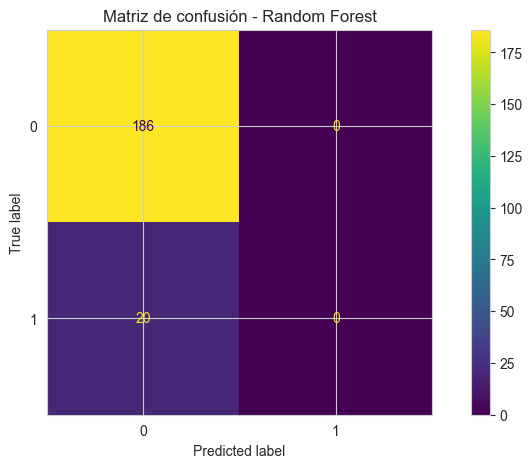

In [19]:
modelo_rf = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        class_weight="balanced"
    ))
])

resultado_rf = evaluar_modelo(
    "Random Forest",
    modelo_rf,
    X_train,
    X_test,
    y_train,
    y_test
)


# 16. Comparación inicial de modelos

Se comparan las métricas principales de los tres modelos probados.


In [20]:
resultados = pd.DataFrame([
    resultado_logistic,
    resultado_tree,
    resultado_rf
])

resultados.sort_values(by="f1_score", ascending=False)


,modelo,accuracy,precision,recall,f1_score
1,Decision Tree,0.762136,0.146341,0.3,0.196721
0,Logistic Regression,0.616505,0.106667,0.4,0.168421
2,Random Forest,0.902913,0.000000,0.0,0.000000


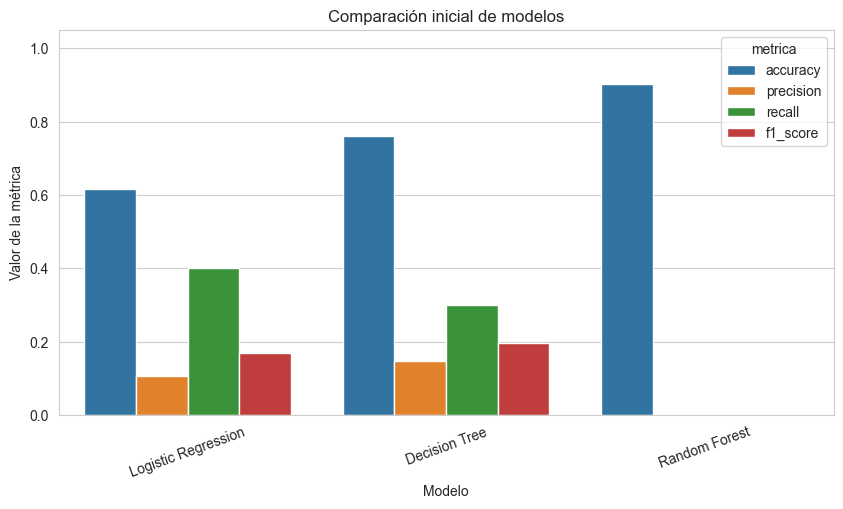

In [21]:
# Visualizamos la comparación de métricas.
resultados_melt = resultados.melt(
    id_vars="modelo",
    value_vars=["accuracy", "precision", "recall", "f1_score"],
    var_name="metrica",
    value_name="valor"
)

sns.barplot(
    data=resultados_melt,
    x="modelo",
    y="valor",
    hue="metrica"
)

plt.title("Comparación inicial de modelos")
plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)

plt.show()


# 17. Conclusiones del modelado inicial

En este notebook se realizó una mejora importante en la definición de la variable objetivo.

Conclusiones principales:

- La variable original `entrega_tardia` presentaba un fuerte desbalance de clases.
- Se creó `entrega_tardia_v2` usando un umbral de más de 7 días.
- Esta nueva definición es más interpretable desde el punto de vista logístico.
- Se entrenaron tres modelos supervisados: Logistic Regression, Decision Tree y Random Forest.
- Se aplicó imputación, escalado y codificación mediante pipelines de Scikit-learn.
- Las métricas obtenidas permiten avanzar hacia una evaluación comparativa más profunda.

La siguiente etapa será analizar los resultados con mayor detalle y luego aplicar optimización de hiperparámetros.
